In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "src")

from pandas import DataFrame
from analytics.metrics.time import TimeMetrics
from spec.enums import MainTableColumns as Cols
from spec.spec_definition import PS2Versions
import pandas as pd

In [26]:
from analytics.preprocessors.edwards import TimeStampToDateTimePreprocessor, ClassSubsetPreprocessor
from analytics.preprocessors.codebench import YAMLLinkURLPreprocessor, CodeBenchAddParentEventIDs
from analytics.preprocessors.codeworkout import CodeWorkoutExtractErrorTypesPreprocessor
from analytics.ps2_dataset import SortPreprocessor
from spec.enums import EventType

config_path = None
problem_id_col = None
timestamp_col = None
idle_gap = None
break_gap = None
mt_preprocessing_steps = []
link_preprocessing_steps = []
submit_event = EventType.Submit
grades_link_table = "Subject"
grades_col = None
start_time = None
end_time = None
early_percentage = None
assignment_ids = None
compile_error_type_col = Cols.CompileMessageType
compile_event = EventType.Compile
compile_error_event = EventType.CompileError
output_suffix = ''

# Note: Only Fall has compilation data; spring has no Run.Program events!
edwards_s19_config = {
    "config_path": "sample_data_configs/edwards2019.yaml",
    "problem_id_col": Cols.AssignmentID,
    "timestamp_col": Cols.ClientTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "mt_preprocessing_steps": [
        # Don't need this, since I've done and cached it
        # AddErrors2021Preprocessor(),
        TimeStampToDateTimePreprocessor(),
        # Make sure this comes last so Fall is correct
        ClassSubsetPreprocessor("Spring"),
    ],
    # Compile error info is stored in the Run.Program event itself
    "compile_event": EventType.RunProgram,
    "end_time": "2019-02-25 00:00:00",
    "early_percentage": 0.23,
    "assignment_ids": ["p4s", "p5s"],  # Only 2 assignments
    "grades_col": "exam2",
    "output_suffix": "-s19",
}

edwards_f19_config = edwards_s19_config.copy()
edwards_f19_config["mt_preprocessing_steps"] = edwards_s19_config["mt_preprocessing_steps"].copy()
edwards_f19_config["mt_preprocessing_steps"][-1] = ClassSubsetPreprocessor("Fall")
edwards_f19_config["end_time"] = "2019-10-13 00:00:00"
edwards_f19_config["assignment_ids"] = ["p4f", "p5f"]
edwards_f19_config["early_percentage"] = 0.42
edwards_f19_config["output_suffix"] = "-f19"

edwards2021_config = {
    "config_path": "sample_data_configs/edwards2021.yaml",
    "problem_id_col": Cols.AssignmentID,
    "timestamp_col": Cols.ClientTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "mt_preprocessing_steps": [
        # Don't need this, since I've done and cached it
        # AddErrors2021Preprocessor(),
        TimeStampToDateTimePreprocessor(),
    ],
    # Compile error info is stored in the Run.Program event itself
    "compile_event": EventType.RunProgram,
    "end_time": "2022-01-01 00:00:00",
    "early_percentage": 0.4,
    "assignment_ids": ["Assign6", "Assign7"],  # Only 2 assignments
    "grades_col": "FinalScore",
}

cwo_s19_config = {
    "config_path": "sample_data_configs/cwo_s19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "mt_preprocessing_steps": [
        SortPreprocessor(),
        CodeWorkoutExtractErrorTypesPreprocessor(),
    ],
    "submit_event": EventType.RunProgram,
    "grades_col": "X-Grade",
    "early_percentage": 0.33,
}

cwo_f19_config = {
    "config_path": "sample_data_configs/cwo_f19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "mt_preprocessing_steps": [
        SortPreprocessor(),
        CodeWorkoutExtractErrorTypesPreprocessor(),
    ],
    "submit_event": EventType.RunProgram,
    "grades_col": "X-Grade",
    "early_percentage": 0.25,
}

codebench2024_config = {
    "config_path": "sample_data_configs/codebench2024.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "link_preprocessing_steps": [YAMLLinkURLPreprocessor(True)],
    "mt_preprocessing_steps": [
        CodeBenchAddParentEventIDs(),
    ],
    "grades_link_table": "CourseSubject",
    "grades_col": "final-grade",
    "start_time": "2024-09-01 00:00:00",
    "early_percentage": 0.28,
    "compile_error_type_col": "ProgramErrorOutput",
    "compile_event": EventType.Submit,
    "compile_error_event": EventType.RunTest,
}

config = cwo_f19_config
# config = cwo_s19_config
# config = codebench2024_config
# config = edwards2021_config
# config = edwards_s19_config
# config = edwards_f19_config
locals().update(config)

In [27]:
from database.config import PS2DataConfig

spec = PS2Versions.v1_0.load()

data_config = PS2DataConfig.from_yaml(config_path, spec)


In [28]:
from analytics.ps2_dataset import PS2Dataset

dataset = PS2Dataset(spec, data_config)
for i, step in enumerate(mt_preprocessing_steps):
    dataset.main_table_preprocessors.insert(i, step)
for i, step in enumerate(link_preprocessing_steps):
    dataset.link_table_preprocessors.insert(i, step)

In [29]:
dataset.main_table_preprocessors

In [30]:
main_table = dataset.get_main_table()
main_table.head()

,SubjectID,ToolInstances,ServerTimestamp,ServerTimezone,CourseID,AssignmentID,ProblemID,Attempt,CodeStateID,IsEventOrderingConsistent,EventType,Score,Compile.Result,CompileMessageType,CompileMessageData,EventID,Order,ParentEventID
0,fd8111a7935742d5d198fb6ba2224bf1b772974b7c17e1...,Java 8; CodeWorkout,2019-09-23 15:14:44,0,CS 1,597,13,1,e03c3817ba234c667140a5281960bfc79238ef075b48c7...,True,Run.Program,0.0,NaN,None,NaN,0,0,NaN
1,fd8111a7935742d5d198fb6ba2224bf1b772974b7c17e1...,Java 8; CodeWorkout,2019-09-23 15:14:44,0,CS 1,597,13,1,e03c3817ba234c667140a5281960bfc79238ef075b48c7...,True,Compile,NaN,Error,None,NaN,1,1,0.0
2,fd8111a7935742d5d198fb6ba2224bf1b772974b7c17e1...,Java 8; CodeWorkout,2019-09-23 15:14:44,0,CS 1,597,13,1,e03c3817ba234c667140a5281960bfc79238ef075b48c7...,True,Compile.Error,NaN,NaN,missing return statement,line 18: error: missing return statement,2,2,1.0
3,fd8111a7935742d5d198fb6ba2224bf1b772974b7c17e1...,Java 8; CodeWorkout,2019-09-23 15:15:13,0,CS 1,597,13,2,cdfe99579672f04db808aa7343826bf3c71751dfba129d...,True,Run.Program,0.0,NaN,None,NaN,3,3,NaN
4,fd8111a7935742d5d198fb6ba2224bf1b772974b7c17e1...,Java 8; CodeWorkout,2019-09-23 15:15:13,0,CS 1,597,13,2,cdfe99579672f04db808aa7343826bf3c71751dfba129d...,True,Compile,NaN,Error,None,NaN,4,4,3.0


In [31]:
main_table[problem_id_col].unique()

array([ 13, 232, 235, 234, 236,   5, 233,   1,   3,  12,  24, 100, 101,
       102,  25,  28,  21,  20,  17,  22,  40,  37, 128,  38,  39,  36,
        32,  31,  33,  34, 106,  49,  41,  43,  44,  46,  67, 104, 108,
       107, 241, 171,  30, 244, 242, 245, 246, 254, 255, 243, 736, 737,
        51,  56,  57,  64,  70,  71, 112, 118])

In [32]:
bad_assignment_ids = [407610653, 1147927607, 1407437764]
main_table = main_table[~main_table[Cols.AssignmentID].isin(bad_assignment_ids)]

In [33]:
if start_time is not None:
    main_table = main_table[main_table[timestamp_col] >= start_time]
if end_time is not None:
    main_table = main_table[main_table[timestamp_col] <= end_time]

In [34]:
if "X-ClassID" in main_table.columns:
    class_counts = main_table["X-ClassID"].value_counts()
    print(class_counts)
    min_count = 1000
    invalid_class_ids = class_counts[class_counts < min_count].index
    print(f"Removing classes with less than {min_count} submissions: {invalid_class_ids}")
    main_table = main_table[~main_table["X-ClassID"].isin(invalid_class_ids) & ~main_table["X-ClassID"].isna()]

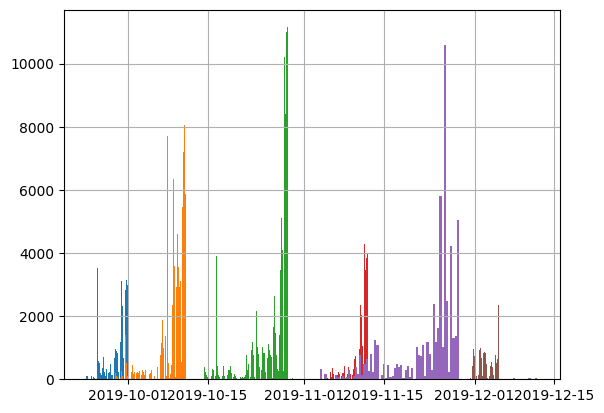

In [35]:
if "X-ClassID" not in main_table.columns:
    main_table.groupby(Cols.AssignmentID)[timestamp_col].hist(bins=100)
else:
    classes = main_table["X-ClassID"].unique()
    classes = classes[~pd.isna(classes)]
    for class_id in classes:
        subset = main_table[main_table["X-ClassID"] == class_id]
        hist = subset.groupby(Cols.AssignmentID)[timestamp_col].hist(bins=100)
        plt.title(f"Class {class_id}")
        plt.show()

In [36]:
import numpy as np
for i in main_table[timestamp_col].quantile(np.arange(0, 1.01, 0.01)).to_list():
    print(i)

2019-09-23 15:14:44
2019-09-25 14:38:38
2019-09-25 18:39:32
2019-09-26 16:14:31
2019-09-27 20:37:48.800000
2019-09-28 21:02:42
2019-09-29 04:44:09.180000
2019-09-29 18:59:35.330000128
2019-09-29 21:21:43.160000
2019-09-30 00:30:44
2019-09-30 02:56:05
2019-09-30 13:17:34
2019-09-30 13:52:49
2019-09-30 15:50:50
2019-09-30 17:51:49
2019-09-30 19:50:43
2019-09-30 22:16:33
2019-10-01 00:51:45
2019-10-01 02:09:37.180000
2019-10-01 03:50:43.840000
2019-10-05 03:07:07.600000
2019-10-07 02:15:21
2019-10-07 20:22:20.140000
2019-10-07 22:29:51
2019-10-08 00:48:04
2019-10-08 03:19:28
2019-10-08 23:01:21.360000
2019-10-09 01:26:35.950000128
2019-10-09 04:07:07
2019-10-09 14:25:46
2019-10-09 18:05:00.900000
2019-10-09 23:26:17
2019-10-10 03:34:03.520000
2019-10-10 15:32:03.610000128
2019-10-10 18:06:37
2019-10-10 20:31:46.949999872
2019-10-10 22:41:35.560000
2019-10-11 00:36:37
2019-10-11 02:22:26
2019-10-14 08:20:59.490000128
2019-10-16 14:54:27
2019-10-19 03:44:19.460000
2019-10-22 22:13:06
2019-1

In [37]:
#get the data of the third quantile
max = main_table[timestamp_col].max()
min = main_table[timestamp_col].min()
range = max - min
time_cutoff = min + range * early_percentage
print(time_cutoff)
print(main_table[timestamp_col].min())
print(main_table[timestamp_col].max())

data_subset = main_table[main_table[timestamp_col] <= time_cutoff]
print("Assignment IDs:", data_subset[Cols.AssignmentID].unique())
if Cols.ProblemID in data_subset.columns:
    print("Problem IDs:", data_subset[Cols.ProblemID].unique())
print("Total number of rows:", len(data_subset))
print("Percent of logs: ", len(data_subset) / len(main_table) * 100)
print(f"Percent of assignments: {len(data_subset[Cols.AssignmentID].unique())} / {len(main_table[Cols.AssignmentID].unique())}")
if Cols.ProblemID in main_table.columns:
    print(f"Percent of problems: {len(data_subset[Cols.ProblemID].unique())} / {len(main_table[Cols.ProblemID].unique())}")
# Assignment IDs: [597 600]
# Problem IDs: [13 232 235 234 236   5 233   1   3  12  24 100 101  25 102  28  21  20  17  22]

2019-10-13 11:22:43
2019-09-23 15:14:44
2019-12-11 23:46:40
Assignment IDs: [597 600]
Problem IDs: [ 13 232 235 234 236   5 233   1   3  12  24 100 101 102  25  28  21  20
  17  22]
Total number of rows: 161703
Percent of logs:  38.94412091961331
Percent of assignments: 2 / 6
Percent of problems: 20 / 60


ProblemID
1      1.000000
3      1.000000
5      1.000000
12     1.000000
13     1.000000
24     1.000000
234    1.000000
235    1.000000
233    1.000000
232    1.000000
101    1.000000
100    1.000000
236    1.000000
22     0.999649
25     0.999610
102    0.999571
28     0.998835
17     0.998191
21     0.997707
20     0.997526
dtype: float64


C:\Users\twprice\AppData\Local\Temp\ipykernel_25824\1718260821.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  problem_percentages = main_table[main_table[problem_id_col].isin(included_problem_ids)].groupby(problem_id_col).apply(lambda x: (x[timestamp_col] < time_cutoff).mean())


<Axes: >

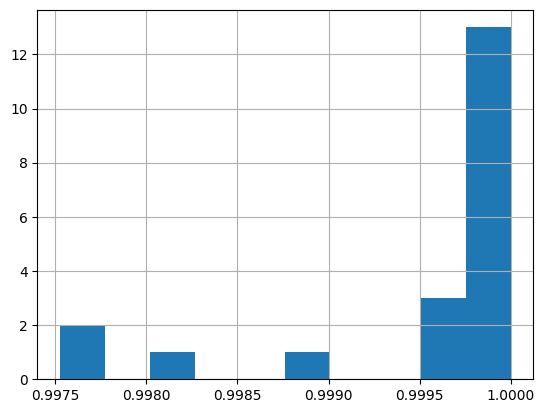

In [38]:
included_problem_ids = data_subset[problem_id_col].unique()
problem_percentages = main_table[main_table[problem_id_col].isin(included_problem_ids)].groupby(problem_id_col).apply(lambda x: (x[timestamp_col] < time_cutoff).mean())
problem_percentages.sort_values(ascending=False, inplace=True)
# Print the whole dataframe, ignoring row limits
with pd.option_context('display.max_rows', None):
    print(problem_percentages)

problem_percentages.hist()


In [39]:
if assignment_ids is not None:
    data_subset = data_subset[data_subset[Cols.AssignmentID].isin(assignment_ids)]

In [40]:
precluded_problems = problem_percentages[problem_percentages < 0.5].index
len_before = len(data_subset)
data_subset = data_subset[~data_subset[problem_id_col].isin(precluded_problems)]
print(f"Precluded problems: {precluded_problems}")
print(f"Removed {100 - 100 * len(data_subset) / len_before:.2f}% of data")

print(f"Percent of assignments: {len(data_subset[Cols.AssignmentID].unique())} / {len(main_table[Cols.AssignmentID].unique())}")
if Cols.ProblemID in main_table.columns:
    print(f"Percent of problems: {len(data_subset[Cols.ProblemID].unique())} / {len(main_table[Cols.ProblemID].unique())}")

Precluded problems: Index([], dtype='int64', name='ProblemID')
Removed 0.00% of data
Percent of assignments: 2 / 6
Percent of problems: 20 / 60


In [41]:
testing_student_subset = data_subset[Cols.SubjectID].unique()[:50]
testing_mt_subset = data_subset[data_subset[Cols.SubjectID].isin(testing_student_subset)]

In [42]:
grouping_cols = ["X-ClassID", Cols.SubjectID, problem_id_col]
grouping_cols = [col for col in grouping_cols if col in main_table.columns]

In [43]:
main_table[compile_error_type_col].value_counts()

CompileMessageType
';' expected                                                27421
illegal start of expression                                  9832
not a statement                                              8796
')' expected                                                 7466
missing return statement                                     6745
                                                            ...  
variable nums is already defined in method tenRun(int[])        1
cannot find symbol: variable flag                               1
cannot find symbol: variable Subtractor                         1
cannot find symbol: method getMaxValue(int[])                   1
cannot find symbol: method replace(int,java.lang.String)        1
Name: count, Length: 3511, dtype: int64

In [44]:
from analytics.metrics.errors import ErrorMetrics


error_metrics = ErrorMetrics(True,
                             compile_message_type_column=compile_error_type_col,
                             compile_event=compile_event,
                             compile_error_event=compile_error_event)

error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)
error_results.head()

C:\Users\twprice\AppData\Local\Temp\ipykernel_25824\4122987523.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)


ErrorQuotient  \
SubjectID                                          ProblemID                  
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 1               0.000000   
                                                   3               0.000000   
                                                   5               0.363636   
                                                   12              0.000000   
                                                   13              0.745455   

                                                              RepeatedErrorDensity  \
SubjectID                                          ProblemID                         
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 1                          0.00   
                                                   3                          0.00   
                                                   5                          0.00   
                                                   12                         0.00   
                                                   13                         2.25   

                                                              FailedCompileCount  
SubjectID                                          ProblemID                      
00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd467... 1                         0.0  
                                                   3                         1.0  
                                                   5                         2.0  
                                                   12                        0.0  
                                                   13                        5.0

In [45]:
# Investigating a single Edwards 2021 student to see why EQ/RED are so low
# Errors tend not to be repeated and there are many successful runs
# data_subset[
#     (data_subset[Cols.SubjectID] == "Student1") &
#     (data_subset[Cols.AssignmentID] == "Assign7") &
#     ((data_subset[Cols.EventType] == EventType.CompileError) | (data_subset[Cols.EventType] == EventType.RunProgram))
# ].head(40)

In [46]:
# EQ is very low for codebench because most runs have no errors
# It's interesting/odd that EQ and RED don't correlate on this dataset

error_results.describe()

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
count,9741.000000,9741.000000,9750.000000
mean,0.140115,0.502854,2.422359
std,0.233110,1.671906,4.662325
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000
75%,0.242424,0.000000,3.000000
max,1.000000,34.938889,80.000000


In [47]:
error_results.corr(method="spearman")

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
ErrorQuotient,1.000000,0.828097,0.841371
RepeatedErrorDensity,0.828097,1.000000,0.739706
FailedCompileCount,0.841371,0.739706,1.000000


<Axes: ylabel='Frequency'>

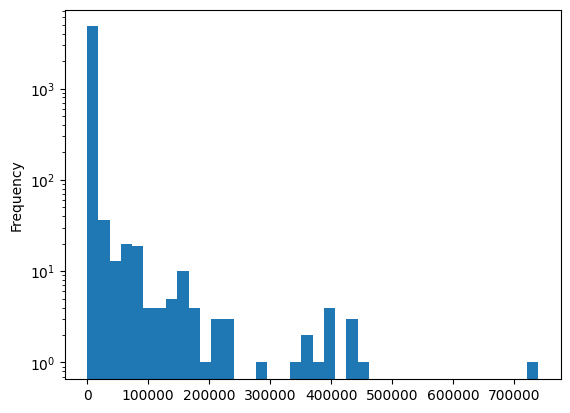

In [48]:
from analytics.metrics.time import TimeMetrics


diffs = TimeMetrics.get_all_diffs(testing_mt_subset, timestamp_col, grouping_cols)
diffs.DeltaSeconds[diffs.DeltaSeconds > 0].plot.hist(bins=40, log=True)

In [49]:
TimeMetrics.get_positive_diff_quantiles(data_subset, timestamp_col, grouping_cols) / 60

# Seems like 5 minutes (90th+ percentile) is a good cutoff for time spent on a problem between submissions
# 30m does seem to suggest that the student is not working on the problem

0.00        0.016667
0.25        0.283333
0.50        0.600000
0.75        1.500000
0.80        1.916667
0.85        2.650000
0.90        4.370000
0.95       16.566667
0.96       35.628667
0.97      107.347667
0.98      450.717333
0.99     1357.943000
1.00    15148.533333
Name: DeltaSeconds, dtype: float64

In [38]:
from analytics.metrics.time import TimeMetrics

time_metrics = TimeMetrics(idle_gap, break_gap, True, timestamp_col)

result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))
result

C:\Users\twprice\AppData\Local\Temp\ipykernel_18548\3223447471.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))


ActiveTime  PassiveTime  TotalTime  \
X-ClassID    SubjectID  ProblemID                                          
9.455914e+08 112044560  1.927447e+09      10.374        0.000     10.374   
             158242931  1.057322e+09     173.882      364.659    538.541   
                        2.559670e+09      82.485       44.671    127.156   
                        3.968058e+09    1012.089      889.924   1902.013   
             188644686  1.463363e+08       0.000        0.000      0.000   
...                                          ...          ...        ...   
3.758479e+09 4215855445 1.092214e+09     143.695       49.690    193.385   
                        1.210323e+09      34.174        0.000     34.174   
                        1.934415e+09       0.000        0.000      0.000   
                        3.306862e+09     132.467        0.000    132.467   
                        4.011688e+09       0.000        0.000      0.000   

                                      ActiveTimeAfterCorrect  #Breaks  \
X-ClassID    SubjectID  ProblemID                                       
9.455914e+08 112044560  1.927447e+09                   0.000        0   
             158242931  1.057322e+09                   0.000        0   
                        2.559670e+09                   0.000        2   
                        3.968058e+09                   4.415        1   
             188644686  1.463363e+08                   0.000        0   
...                                                      ...      ...   
3.758479e+09 4215855445 1.092214e+09                   0.000        0   
                        1.210323e+09                   0.000        0   
                        1.934415e+09                   0.000        0   
                        3.306862e+09                   0.000        0   
                        4.011688e+09                   0.000        0   

                                                   StartTime  \
X-ClassID    SubjectID  ProblemID                              
9.455914e+08 112044560  1.927447e+09 2024-09-12 23:24:18.089   
             158242931  1.057322e+09 2024-09-17 22:58:08.625   
                        2.559670e+09 2024-09-17 22:36:34.682   
                        3.968058e+09 2024-09-17 22:16:09.607   
             188644686  1.463363e+08 2024-09-03 22:26:43.720   
...                                                      ...   
3.758479e+09 4215855445 1.092214e+09 2024-09-11 14:13:03.675   
                        1.210323e+09 2024-09-11 14:05:27.536   
                        1.934415e+09 2024-09-04 14:41:17.410   
                        3.306862e+09 2024-09-11 14:10:40.523   
                        4.011688e+09 2024-09-04 14:39:55.670   

                                            FirstCorrectTime  \
X-ClassID    SubjectID  ProblemID                              
9.455914e+08 112044560  1.927447e+09                     NaT   
             158242931  1.057322e+09                     NaT   
                        2.559670e+09                     NaT   
                        3.968058e+09 2024-09-17 22:52:24.660   
             188644686  1.463363e+08 2024-09-03 22:26:43.720   
...                                                      ...   
3.758479e+09 4215855445 1.092214e+09 2024-09-11 14:16:17.060   
                        1.210323e+09 2024-09-11 14:06:01.710   
                        1.934415e+09 2024-09-04 14:41:17.410   
                        3.306862e+09 2024-09-11 14:12:52.990   
                        4.011688e+09 2024-09-04 14:39:55.670   

                                                     EndTime  
X-ClassID    SubjectID  ProblemID                             
9.455914e+08 112044560  1.927447e+09 2024-09-12 23:24:28.463  
             158242931  1.057322e+09 2024-09-17 23:07:07.166  
                        2.559670e+09 2024-09-17 22:53:20.064  
                        3.968058e+09 2024-09-17 22:58:05.066  
             188644686  1.463363e+08 2024-09-03 22:26:4

In [39]:
result.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
count,6.126000e+03,6126.000000,6126.000000,6126.000000,6126.000000,6126,5479,6126
mean,2.379133e+02,149.314935,387.228279,8.504795,0.589944,2024-09-10 04:10:49.038443264,2024-09-10 00:07:08.193500416,2024-09-10 18:23:53.104193792
min,-5.684342e-14,0.000000,0.000000,0.000000,0.000000,2024-09-01 01:35:32.500000,2024-09-01 03:52:26.560000,2024-09-01 03:52:26.560000
25%,0.000000e+00,0.000000,0.000000,0.000000,0.000000,2024-09-04 15:48:12.757500160,2024-09-04 15:08:28.600000,2024-09-04 19:39:20.642500096
50%,1.046485e+02,43.032500,181.749000,0.000000,0.000000,2024-09-10 19:01:20.840999936,2024-09-10 18:29:50.129999872,2024-09-11 02:01:24.619500032
75%,3.497060e+02,192.426250,533.135000,0.000000,1.000000,2024-09-13 18:19:15.697250048,2024-09-12 22:52:10.305000192,2024-09-16 14:58:54.600000
max,6.947802e+03,6630.387000,13578.189000,1452.270000,51.000000,2024-09-21 22:39:08.412000,2024-09-21 22:45:31.910000,2024-09-22 01:22:49.720000
std,3.631073e+02,276.664718,597.075872,48.218304,1.497205,NaN,NaN,NaN


In [40]:
result.corr(method="spearman")

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
ActiveTime,1.000000,0.712288,0.945273,0.108132,0.423481,0.670651,0.533732,0.673176
PassiveTime,0.712288,1.000000,0.879034,0.124260,0.498522,0.366967,0.274631,0.403680
TotalTime,0.945273,0.879034,1.000000,0.124144,0.482558,0.593727,0.467887,0.609378
ActiveTimeAfterCorrect,0.108132,0.124260,0.124144,1.000000,0.070878,0.013645,0.136832,0.119137
#Breaks,0.423481,0.498522,0.482558,0.070878,1.000000,0.136779,0.068049,0.226814
StartTime,0.670651,0.366967,0.593727,0.013645,0.136779,1.000000,0.664077,0.940160
FirstCorrectTime,0.533732,0.274631,0.467887,0.136832,0.068049,0.664077,1.000000,0.649906
EndTime,0.673176,0.403680,0.609378,0.119137,0.226814,0.940160,0.649906,1.000000


In [41]:
result["FirstCorrectTime"].isna().mean()

np.float64(0.10561540972902383)

In [42]:
result["StartTime"].isna().mean()

np.float64(0.0)

In [43]:
from analytics.metrics.score import SubmissionScoreMetrics
from spec.enums import EventType

score_metrics = SubmissionScoreMetrics(submit_event)

subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


C:\Users\twprice\AppData\Local\Temp\ipykernel_18548\1178317524.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


In [44]:
subject_problem_score.head()

Attempts  FirstCorrect  EverCorrect  \
X-ClassID   SubjectID ProblemID                                           
945591435.0 112044560 1.927447e+09         0         False        False   
            158242931 1.057322e+09         0         False        False   
                      2.559670e+09         0         False        False   
                      3.968058e+09         1          True         True   
            188644686 1.463363e+08         1          True         True   

                                    Attempted  MaxScore  MinScore  MeanScore  \
X-ClassID   SubjectID ProblemID                                                
945591435.0 112044560 1.927447e+09      False       0.0       0.0        0.0   
            158242931 1.057322e+09      False       0.0       0.0        0.0   
                      2.559670e+09      False       0.0       0.0        0.0   
                      3.968058e+09       True       1.0       1.0        1.0   
            188644686 1.463363e+08       True       1.0       1.0        1.0   

                                    TotalAttempts  
X-ClassID   SubjectID ProblemID                    
945591435.0 112044560 1.927447e+09              0  
            158242931 1.057322e+09              0  
                      2.559670e+09              0  
                      3.968058e+09              2  
            188644686 1.463363e+08              1

In [45]:
subject_problem_score.describe()

,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts
count,6126.000000,6126.000000,6126.000000,6126.000000,6126.000000
mean,3.366471,0.895745,0.535151,0.644288,3.709272
std,7.187316,0.304546,0.493061,0.401263,7.536439
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.250000,1.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000
75%,3.000000,1.000000,1.000000,1.000000,3.000000
max,212.000000,1.000000,1.000000,1.000000,212.000000


In [46]:
all_features = pd.merge(
    result.reset_index(),
    subject_problem_score.reset_index(),
    on=grouping_cols,
    how="outer"
)
all_features = pd.merge(
    all_features,
    error_results.reset_index(),
    on=grouping_cols,
    how="outer"
)
all_features.head()

,X-ClassID,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,...,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
0,945591435.0,112044560,1.927447e+09,10.374,0.000,10.374,0.000,0,2024-09-12 23:24:18.089,NaT,...,False,False,False,0.0,0.0,0.0,0,NaN,NaN,0.0
1,945591435.0,158242931,1.057322e+09,173.882,364.659,538.541,0.000,0,2024-09-17 22:58:08.625,NaT,...,False,False,False,0.0,0.0,0.0,0,NaN,NaN,0.0
2,945591435.0,158242931,2.559670e+09,82.485,44.671,127.156,0.000,2,2024-09-17 22:36:34.682,NaT,...,False,False,False,0.0,0.0,0.0,0,NaN,NaN,0.0
3,945591435.0,158242931,3.968058e+09,1012.089,889.924,1902.013,4.415,1,2024-09-17 22:16:09.607,2024-09-17 22:52:24.660,...,True,True,True,1.0,1.0,1.0,2,1.0,0.5,2.0
4,945591435.0,188644686,1.463363e+08,0.000,0.000,0.000,0.000,0,2024-09-03 22:26:43.720,2024-09-03 22:26:43.720,...,True,True,True,1.0,1.0,1.0,1,NaN,NaN,1.0


In [47]:
all_features.isna().mean()

X-ClassID                 0.000000
SubjectID                 0.000000
ProblemID                 0.000000
ActiveTime                0.000000
PassiveTime               0.000000
TotalTime                 0.000000
ActiveTimeAfterCorrect    0.000000
#Breaks                   0.000000
StartTime                 0.000000
FirstCorrectTime          0.105615
EndTime                   0.000000
Attempts                  0.000000
FirstCorrect              0.000000
EverCorrect               0.000000
Attempted                 0.000000
MaxScore                  0.000000
MinScore                  0.000000
MeanScore                 0.000000
TotalAttempts             0.000000
ErrorQuotient             0.525792
RepeatedErrorDensity      0.525792
FailedCompileCount        0.000000
dtype: float64

In [48]:
median_features = all_features.groupby(problem_id_col)[[TimeMetrics.ACTIVE_TIME, SubmissionScoreMetrics.MAX_SCORE]].median()
all_features_with_median = all_features.merge(
    median_features,
    on=problem_id_col,
    suffixes=("", "_median"),
    how="left"
)
all_features["AtLeatMedianActiveTime"] = (all_features[TimeMetrics.ACTIVE_TIME] >= all_features_with_median[TimeMetrics.ACTIVE_TIME + "_median"]) + 0
all_features["AtLeatMedianMaxScore"] = (all_features[SubmissionScoreMetrics.MAX_SCORE] >= all_features_with_median[SubmissionScoreMetrics.MAX_SCORE + "_median"]) + 0
all_features["HadEffort"] = all_features["AtLeatMedianActiveTime"] | all_features["AtLeatMedianMaxScore"]
all_features.describe()

,X-ClassID,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
count,6.126000e+03,6.126000e+03,6.126000e+03,6.126000e+03,6126.000000,6126.000000,6126.000000,6126.000000,6126,5479,...,6126.000000,6126.000000,6126.000000,6126.000000,2905.000000,2905.000000,6126.000000,6126.000000,6126.000000,6126.000000
mean,2.677153e+09,2.134521e+09,2.181492e+09,2.379133e+02,149.314935,387.228279,8.504795,0.589944,2024-09-10 04:10:49.038443264,2024-09-10 00:07:08.193500416,...,0.895745,0.535151,0.644288,3.709272,0.969908,4.531083,3.709272,0.603657,0.894385,0.951845
min,9.455914e+08,1.310882e+07,4.868418e+07,-5.684342e-14,0.000000,0.000000,0.000000,0.000000,2024-09-01 01:35:32.500000,2024-09-01 03:52:26.560000,...,0.000000,0.000000,0.000000,0.000000,0.727273,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.298943e+09,1.008349e+09,1.076448e+09,0.000000e+00,0.000000,0.000000,0.000000,0.000000,2024-09-04 15:48:12.757500160,2024-09-04 15:08:28.600000,...,1.000000,0.000000,0.250000,1.000000,0.979021,0.500000,1.000000,0.000000,1.000000,1.000000
50%,2.607741e+09,2.164738e+09,2.132967e+09,1.046485e+02,43.032500,181.749000,0.000000,0.000000,2024-09-10 19:01:20.840999936,2024-09-10 18:29:50.129999872,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.333333,1.000000,1.000000,1.000000,1.000000
75%,3.648409e+09,3.148988e+09,3.455942e+09,3.497060e+02,192.426250,533.135000,0.000000,1.000000,2024-09-13 18:19:15.697250048,2024-09-12 22:52:10.305000192,...,1.000000,1.000000,1.000000,3.000000,1.000000,5.142857,3.000000,1.000000,1.000000,1.000000
max,3.758479e+09,4.275215e+09,4.233866e+09,6.947802e+03,6630.387000,13578.189000,1452.270000,51.000000,2024-09-21 22:39:08.412000,2024-09-21 22:45:31.910000,...,1.000000,1.000000,1.000000,212.000000,1.000000,207.022234,212.000000,1.000000,1.000000,1.000000
std,1.038222e+09,1.254812e+09,1.312533e+09,3.631073e+02,276.664718,597.075872,48.218304,1.497205,NaN,NaN,...,0.304546,0.493061,0.401263,7.536439,0.066704,9.074375,7.536439,0.489177,0.307370,0.214112


In [49]:
all_features_z = all_features.copy()

time_cols = [
    TimeMetrics.START_TIME,
    TimeMetrics.FIRST_CORRECT_TIME,
    TimeMetrics.END_TIME,
]

all_features_z[time_cols] = all_features_z[time_cols].astype('int64') / 1e9
numeric_cols = all_features_z.select_dtypes(include=["number"]).columns
# remove the grouping columns from numeric_cols
numeric_cols = numeric_cols.difference(grouping_cols)
all_features_z[numeric_cols] = all_features_z.groupby(problem_id_col)[numeric_cols].transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))


In [50]:
all_features_z.head()

,X-ClassID,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
0,945591435.0,112044560,1.927447e+09,-0.494177,-0.569686,-0.561906,-0.175849,-0.478578,1.677975,-3.215685,...,-3.215685,-1.028469,-1.602820,-0.730212,NaN,NaN,-0.730212,0.000000,-3.215685,0.000000
1,945591435.0,158242931,1.057322e+09,-0.410158,0.304318,-0.143141,-0.348785,-0.578088,1.212428,-1.313579,...,-1.313579,-0.716498,-1.034503,-0.746534,NaN,NaN,-0.746534,-1.028992,-1.313579,-1.313579
2,945591435.0,158242931,2.559670e+09,-0.991146,-0.754208,-0.980870,-0.476213,1.292837,1.353819,-1.845200,...,-1.845200,-0.503236,-1.129168,-1.009688,NaN,NaN,-1.009688,-0.963624,-1.845200,-1.845200
3,945591435.0,158242931,3.968058e+09,1.155538,2.217921,1.667202,0.029898,0.298541,0.673027,0.449136,...,0.449089,0.914659,0.865124,-0.314786,0.806915,-0.549511,-0.314786,0.914659,0.449089,0.242536
4,945591435.0,188644686,1.463363e+08,-0.499051,-0.567312,-0.559024,-0.187739,-0.463748,-0.663373,0.329387,...,0.329469,1.098231,1.039117,-0.580941,NaN,NaN,-0.580941,-1.005479,0.329469,0.239793


In [51]:
all_features_z.RepeatedErrorDensity.isna().mean()

np.float64(0.5257917074763304)

In [52]:
all_na_eq = all_features.groupby(Cols.SubjectID).ErrorQuotient.apply(lambda x: pd.isna(x).all())
all_na_eq = all_na_eq[all_na_eq]
all_na_eq

SubjectID
112044560     True
168966594     True
287168727     True
456016787     True
477252290     True
904953019     True
955045871     True
1017475257    True
1175763119    True
1214728740    True
1400890297    True
1489631879    True
1584616107    True
1682474731    True
1712920939    True
2371903107    True
2388256559    True
2788499525    True
2803773334    True
2808189831    True
2808222414    True
2947028959    True
3026032920    True
3429343515    True
3449088692    True
3657519975    True
4185351836    True
4200061691    True
4207632686    True
Name: ErrorQuotient, dtype: bool

In [53]:
# In CWO, this student attempted all of 1 problem, got and error and gave up
# I think assigning a 1 makes more sense than a 0... but 0 is more generic and
# it's rare enough I'm not going to worry about it right now
data_subset[data_subset[Cols.SubjectID].isin(all_na_eq.index)]

,EventID,EventType,Order,SubjectID,CodeStateID,ProjectID,ToolInstances,ServerTimestamp,AssignmentID,ProblemID,...,ExecutionResult,X-ExecutionTime,ProgramInput,ProgramOutput,ProgramErrorOutput,EditType,X-InsertText,SourceLocation,CodeStateSection,ParentEventID
29411,75773,Session.Start,29411,904953019,NaN,NaN,NaN,2024-09-02 10:19:42.820,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29416,75795,Session.End,29416,904953019,NaN,NaN,NaN,2024-09-02 10:53:14.980,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30334,76340,Session.Start,30334,2808189831,NaN,NaN,NaN,2024-09-02 14:33:35.790,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30593,76438,Session.End,30593,2808189831,NaN,NaN,NaN,2024-09-02 14:46:46.680,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35025,78409,Session.Start,35025,904953019,NaN,NaN,NaN,2024-09-02 21:42:53.080,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1334018,5117578,Run.Test,1334018,904953019,4c5488a8c0193134b8584261af654101c4a0df6f,2770682752_1106645573,Python 3.8.5,2024-09-20 18:55:07.190,2.770683e+09,1.106646e+09,...,Success,NaN,Resources/Input/2770682752_904953019.txt,Resources/Output/2770682752_904953019.txt,NaN,NaN,NaN,NaN,NaN,28584.0
1334019,5117579,Run.Test,1334019,904953019,4c5488a8c0193134b8584261af654101c4a0df6f,2770682752_1106645573,Python 3.8.5,2024-09-20 18:55:07.190,2.770683e+09,1.106646e+09,...,Success,NaN,Resources/Input/2770682752_904953019.txt,Resources/Output/2770682752_904953019.txt,NaN,NaN,NaN,NaN,NaN,28584.0
1364400,153863,Session.Start,1364400,904953019,NaN,NaN,NaN,2024-09-21 08:29:26.220,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1364402,153867,Session.End,1364402,904953019,NaN,NaN,NaN,2024-09-21 08:39:42.770,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
merge_cols = grouping_cols.copy()
merge_cols.remove(problem_id_col)
merge_cols = [col for col in merge_cols if col in all_features_z.columns]

subject_means = all_features_z.drop(problem_id_col, axis=1).groupby(merge_cols).mean()
# In theory this can happen is someone only has NA for all problems
# This apparently happened with EQ in CWO...

# For EQ, having no attempts with compile errors should give you
# the max value (whatever 1 is after normalization)
for col in [ErrorMetrics.ERROR_QUOTIENT]:
    max_val = subject_means[col].max()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(max_val)

# But for RED it should be the minimum value (normalized 0)
for col in [ErrorMetrics.REPEATED_ERROR_DENSITY, SubmissionScoreMetrics.MAX_SCORE, SubmissionScoreMetrics.MEAN_SCORE, SubmissionScoreMetrics.MIN_SCORE]:
    min_val = subject_means[col].min()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(min_val)

subject_means.head()

ActiveTime  PassiveTime  TotalTime  \
X-ClassID   SubjectID                                       
945591435.0 112044560   -0.494177    -0.569686  -0.561906   
            158242931   -0.081922     0.589344   0.181064   
            188644686   -0.492325    -0.410954  -0.510523   
            280846303   -0.380819    -0.482743  -0.437578   
            414686080    0.777407     0.657823   0.775925   

                       ActiveTimeAfterCorrect   #Breaks  StartTime  \
X-ClassID   SubjectID                                                
945591435.0 112044560               -0.175849 -0.478578   1.677975   
            158242931               -0.265033  0.337763   1.079758   
            188644686               -0.219057 -0.357268  -0.641676   
            280846303               -0.246561 -0.266315   0.982964   
            414686080               -0.177641  0.226914   0.464605   

                       FirstCorrectTime   EndTime  Attempts  FirstCorrect  \
X-ClassID   SubjectID                                                       
945591435.0 112044560         -3.215685  1.274810 -0.691515      0.000000   
            158242931         -0.903214  1.081290 -0.718592      0.333333   
            188644686          0.243919 -0.774720 -0.338836      0.727273   
            280846303         -3.606372  0.663749 -0.320550      0.000000   
            414686080         -0.177519  0.359010  0.156032      0.333333   

                       ...  MaxScore  MinScore  MeanScore  TotalAttempts  \
X-ClassID   SubjectID  ...                                                 
945591435.0 112044560  ... -3.215685 -1.028469  -1.602820      -0.730212   
            158242931  ... -0.903230 -0.101692  -0.432849      -0.690336   
            188644686  ...  0.279475  0.421797   0.515825      -0.354754   
            280846303  ... -3.758503 -0.966686  -1.669050      -0.337874   
            414686080  ... -0.194006 -0.416333  -0.472851       0.082924   

                       ErrorQuotient  RepeatedErrorDensity  \
X-ClassID   SubjectID                                        
945591435.0 112044560       0.931488             -0.733408   
            158242931       0.806915             -0.549511   
            188644686      -0.440253             -0.462734   
            280846303       0.931488             -0.733408   
            414686080       0.155126              0.149768   

                       FailedCompileCount  AtLeatMedianActiveTime  \
X-ClassID   SubjectID                                               
945591435.0 112044560           -0.730212                0.000000   
            158242931           -0.690336               -0.359319   
            188644686           -0.354754               -0.451832   
            280846303           -0.337874                0.991155   
            414686080            0.082924                0.561397   

                       AtLeatMedianMaxScore  HadEffort  
X-ClassID   SubjectID                                   
945591435.0 112044560             -3.215685   0.000000  
            158242931             -0.903230  -0.972081  
            188644686              0.279475   0.091956  
            280846303             -3.606372   0.155238  
            414686080             -0.191287   0.155695  

[5 rows x 22 columns]

In [55]:
subject_totals = all_features_z.drop(problem_id_col, axis=1).groupby(merge_cols).sum()
subject_totals.head()

ActiveTime  PassiveTime  TotalTime  \
X-ClassID   SubjectID                                       
945591435.0 112044560   -0.494177    -0.569686  -0.561906   
            158242931   -0.245766     1.768031   0.543192   
            188644686  -10.831146    -9.040990 -11.231504   
            280846303   -0.380819    -0.482743  -0.437578   
            414686080   32.651084    27.628571  32.588833   

                       ActiveTimeAfterCorrect   #Breaks  StartTime  \
X-ClassID   SubjectID                                                
945591435.0 112044560               -0.175849 -0.478578   1.677975   
            158242931               -0.795100  1.013290   3.239274   
            188644686               -4.819251 -7.859897 -14.116882   
            280846303               -0.246561 -0.266315   0.982964   
            414686080               -7.460919  9.530372  19.513427   

                       FirstCorrectTime    EndTime  Attempts  FirstCorrect  \
X-ClassID   SubjectID                                                        
945591435.0 112044560         -3.215685   1.274810 -0.691515             0   
            158242931         -2.709643   3.243871 -2.155776             1   
            188644686          5.366221 -17.043834 -7.454400            16   
            280846303         -3.606372   0.663749 -0.320550             0   
            414686080         -7.455778  15.078404  6.553357            14   

                       ...  MaxScore   MinScore  MeanScore  TotalAttempts  \
X-ClassID   SubjectID  ...                                                  
945591435.0 112044560  ... -3.215685  -1.028469  -1.602820      -0.730212   
            158242931  ... -2.709690  -0.305075  -1.298547      -2.071009   
            188644686  ...  6.148448   9.279542  11.348147      -7.804580   
            280846303  ... -3.758503  -0.966686  -1.669050      -0.337874   
            414686080  ... -8.148268 -17.485980 -19.859757       3.482820   

                       ErrorQuotient  RepeatedErrorDensity  \
X-ClassID   SubjectID                                        
945591435.0 112044560       0.000000              0.000000   
            158242931       0.806915             -0.549511   
            188644686      -3.522023             -3.701875   
            280846303       0.000000              0.000000   
            414686080       3.257636              3.145126   

                       FailedCompileCount  AtLeatMedianActiveTime  \
X-ClassID   SubjectID                                               
945591435.0 112044560           -0.730212                0.000000   
            158242931           -2.071009               -1.077957   
            188644686           -7.804580               -9.940308   
            280846303           -0.337874                0.991155   
            414686080            3.482820               23.578694   

                       AtLeatMedianMaxScore  HadEffort  
X-ClassID   SubjectID                                   
945591435.0 112044560             -3.215685   0.000000  
            158242931             -2.709690  -2.916243  
            188644686              6.148448   2.023041  
            280846303             -3.606372   0.155238  
            414686080             -8.034059   6.539206  

[5 rows x 22 columns]

In [56]:
subject_features = pd.merge(
    subject_means.reset_index(),
    subject_totals.reset_index(),
    on=merge_cols,
    how="outer",
    suffixes=('_mean', '_sum')
)
subject_features.head()

,X-ClassID,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,945591435.0,112044560,-0.494177,-0.569686,-0.561906,-0.175849,-0.478578,1.677975,-3.215685,1.274810,...,-3.215685,-1.028469,-1.602820,-0.730212,0.000000,0.000000,-0.730212,0.000000,-3.215685,0.000000
1,945591435.0,158242931,-0.081922,0.589344,0.181064,-0.265033,0.337763,1.079758,-0.903214,1.081290,...,-2.709690,-0.305075,-1.298547,-2.071009,0.806915,-0.549511,-2.071009,-1.077957,-2.709690,-2.916243
2,945591435.0,188644686,-0.492325,-0.410954,-0.510523,-0.219057,-0.357268,-0.641676,0.243919,-0.774720,...,6.148448,9.279542,11.348147,-7.804580,-3.522023,-3.701875,-7.804580,-9.940308,6.148448,2.023041
3,945591435.0,280846303,-0.380819,-0.482743,-0.437578,-0.246561,-0.266315,0.982964,-3.606372,0.663749,...,-3.758503,-0.966686,-1.669050,-0.337874,0.000000,0.000000,-0.337874,0.991155,-3.606372,0.155238
4,945591435.0,414686080,0.777407,0.657823,0.775925,-0.177641,0.226914,0.464605,-0.177519,0.359010,...,-8.148268,-17.485980,-19.859757,3.482820,3.257636,3.145126,3.482820,23.578694,-8.034059,6.539206


In [57]:
subject_features.isna().mean()[subject_features.isna().mean() != 0]

Series([], dtype: float64)

In [58]:
assert subject_features.isna().mean().mean() == 0

In [59]:
subject_feautres_z = subject_features.copy()
numeric_cols = subject_feautres_z.select_dtypes(include=["number"]).columns
numeric_cols = numeric_cols.difference(merge_cols)
subject_feautres_z[numeric_cols] = subject_feautres_z[numeric_cols].apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1), axis=0)
subject_feautres_z.head()

,X-ClassID,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,945591435.0,112044560,-0.514863,-0.862984,-0.658383,-0.288089,-0.855853,2.029474,-1.785601,1.687253,...,-0.357694,-0.094745,-0.135168,-0.065853,7.674984e-17,2.903202e-17,-0.065853,3.778503e-17,-0.358776,0.000000
1,945591435.0,158242931,0.177045,1.448710,0.612855,-0.582442,1.172337,1.266715,-0.108300,1.425594,...,-0.301410,-0.028104,-0.109508,-0.186770,2.379455e-01,-8.756451e-02,-0.186770,-9.780779e-02,-0.302322,-0.479126
2,945591435.0,188644686,-0.511755,-0.546391,-0.570465,-0.430697,-0.554460,-0.928207,0.723748,-1.083925,...,0.683917,0.854854,0.957004,-0.703840,-1.038585e+00,-5.898931e-01,-0.703840,-9.019284e-01,0.685987,0.332377
3,945591435.0,280846303,-0.324609,-0.689574,-0.445654,-0.521474,-0.328490,1.143298,-2.068977,0.861034,...,-0.418074,-0.089053,-0.140753,-0.030470,7.674984e-17,2.903202e-17,-0.030470,8.993188e-02,-0.402365,0.025505
4,945591435.0,414686080,1.619299,1.585293,1.630674,-0.294003,0.896932,0.482363,0.418067,0.448995,...,-0.906365,-1.610852,-1.674800,0.314091,9.606221e-01,5.011753e-01,0.314091,2.139400e+00,-0.896366,1.074363


In [60]:
grades = dataset.get_link_table(grades_link_table)
grades.head()

,CourseID,SubjectID,URL,approved,final-grade
0,919753123,2596793261,Resources/FinalGrade/919753123_2596793261.yaml,False,0.00
1,919753123,3143505766,Resources/FinalGrade/919753123_3143505766.yaml,False,0.00
2,919753123,3624632776,Resources/FinalGrade/919753123_3624632776.yaml,False,0.44
3,919753123,3215542955,Resources/FinalGrade/919753123_3215542955.yaml,False,3.38
4,919753123,904953019,Resources/FinalGrade/919753123_904953019.yaml,False,0.00


In [61]:
grades.rename(columns={
    grades_col: "Grade",
    # Edwards 2019 calls it Group
    "Group": "X-ClassID",
    # CodeBench has this mislabeled
    "CourseID": "X-ClassID"},
inplace=True)

# Drop 0 grades, since they're likely students who skipped the test
print(f"Dropping {grades[grades['Grade'] <= 0].shape[0]} rows with 0 grades")
grades = grades[grades["Grade"] > 0]

Dropping 189 rows with 0 grades


In [62]:
print(f"Merging on columns: {merge_cols}")

subject_feautres_labeled = pd.merge(
    subject_feautres_z,
    grades[merge_cols + ["Grade"]],
    on=merge_cols,
    how="inner",
)

Merging on columns: ['X-ClassID', <MainTableColumns.SubjectID: 'SubjectID'>]


In [63]:
print(subject_features.shape)
subject_feautres_labeled.head()

(273, 46)


,X-ClassID,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum,Grade
0,945591435.0,158242931,0.177045,1.448710,0.612855,-0.582442,1.172337,1.266715,-0.108300,1.425594,...,-0.028104,-0.109508,-0.186770,0.237946,-0.087565,-0.186770,-0.097808,-0.302322,-0.479126,1.49
1,945591435.0,188644686,-0.511755,-0.546391,-0.570465,-0.430697,-0.554460,-0.928207,0.723748,-1.083925,...,0.854854,0.957004,-0.703840,-1.038585,-0.589893,-0.703840,-0.901928,0.685987,0.332377,8.75
2,945591435.0,414686080,1.619299,1.585293,1.630674,-0.294003,0.896932,0.482363,0.418067,0.448995,...,-1.610852,-1.674800,0.314091,0.960622,0.501175,0.314091,2.139400,-0.896366,1.074363,5.66
3,945591435.0,530793764,0.990010,1.225300,1.079073,-0.158475,0.343816,0.591473,0.411013,0.589181,...,0.607262,0.375839,-0.893734,0.250502,-0.569959,-0.893734,0.355421,-0.644424,-0.083449,3.12
4,945591435.0,873175644,2.180400,2.315075,2.131847,-0.802892,0.134520,1.576508,-1.049440,1.559539,...,-0.177767,-0.218191,0.304906,0.161521,0.390559,0.304906,0.095874,-0.491079,0.056451,3.42


In [64]:
assert subject_feautres_labeled.groupby(merge_cols).Grade.count().max() == 1

In [65]:
print(len(subject_feautres_labeled))
dir = os.path.join(dataset.data_config.root_path, f"analysis{output_suffix}")
if not os.path.exists(dir):
    os.makedirs(dir)
subject_feautres_labeled.to_csv(os.path.join(dir, f"subject_features.csv"), index=False)

205
